# Game Score Prediction Summary Notebook

This notebook turns the Streamlit workflow in this repository into a single reproducible analysis. It covers:

- exploratory data analysis (EDA)
- model training for linear, ridge, and lasso regression
- model testing on a held-out split
- a supplementary Gaussian Naive Bayes classification experiment
- metric explanations and model visualizations

The notebook uses the merged GRIVG dataset in `datasets/merged_grivg_data.csv` and keeps the same cleaning logic used by the app wherever possible.

In [1]:
from pathlib import Path
import re

from IPython.display import display
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

RANDOM_STATE = 45
TEST_SIZE = 0.30
NB_HIGH_SCORE_THRESHOLD = 9.0
IGN_HIGH_THRESHOLD = 0.95
IGN_LOW_THRESHOLD = 0.9
DATASET_PATH = Path("../datasets/merged_grivg_data.csv") if Path("../datasets/merged_grivg_data.csv").exists() else Path("datasets/merged_grivg_data.csv")
NOTEBOOK_STATE = {}

In [2]:
def clean_column_name(column):
    column = str(column).strip()
    column = re.sub(r"[\s\-]+", "_", column)
    column = re.sub(r"[^0-9a-zA-Z_]", "", column)
    column = re.sub(r"_+", "_", column)
    return column.strip("_")


def parse_percentage(series):
    cleaned = (
        series.astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan, "Unknown": np.nan})
    )
    values = pd.to_numeric(cleaned, errors="coerce")
    if not values.dropna().empty and values.dropna().max() > 1:
        values = values / 100
    return values


def split_dataset(X, y, number, random_state=45):
    return train_test_split(
        X,
        y,
        test_size=number / 100,
        random_state=random_state,
    )


def flatten(values):
    return np.asarray(values, dtype=float).reshape(-1)


def rmse(y_true, y_pred):
    y_true = flatten(y_true)
    y_pred = flatten(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true, y_pred):
    y_true = flatten(y_true)
    y_pred = flatten(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def r2(y_true, y_pred):
    y_true = flatten(y_true)
    y_pred = flatten(y_pred)
    total_sum_squares = np.sum((y_true - np.mean(y_true)) ** 2)
    if total_sum_squares == 0:
        return 0.0
    residual_sum_squares = np.sum((y_true - y_pred) ** 2)
    return float(1 - (residual_sum_squares / total_sum_squares))


def mse(y_true, y_pred):
    y_true = flatten(y_true)
    y_pred = flatten(y_pred)
    return float(np.mean((y_true - y_pred) ** 2))


def accuracy(y_true, y_pred):
    y_true = flatten(y_true)
    y_pred = flatten(y_pred)
    return float(np.mean(y_true == y_pred))


def precision(y_true, y_pred):
    y_true = flatten(y_true)
    y_pred = flatten(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return float(tp / (tp + fp + 1e-8))


def recall(y_true, y_pred):
    y_true = flatten(y_true)
    y_pred = flatten(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return float(tp / (tp + fn + 1e-8))


def f1_score(y_true, y_pred):
    metric_precision = precision(y_true, y_pred)
    metric_recall = recall(y_true, y_pred)
    return float(2 * metric_precision * metric_recall / (metric_precision + metric_recall + 1e-8))


METRICS_MAP = {
    "mean_absolute_error": mae,
    "mean_squared_error": mse,
    "root_mean_squared_error": rmse,
    "r2_score": r2,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1_score,
}


def compute_eval_metrics(X, y_true, model, metrics):
    y_pred = model.predict(X)
    return {metric: METRICS_MAP[metric](y_true, y_pred) for metric in metrics}


def restore_data(df, features, target, split_pct=30, state=None):
    state = NOTEBOOK_STATE if state is None else state
    cached_state = state.get("train_state")
    if cached_state is not None:
        return cached_state

    modeling_df = df[features + [target]].dropna().copy()
    X = modeling_df[features].to_numpy(dtype=float)
    y = modeling_df[target].to_numpy(dtype=float).reshape(-1, 1)
    X_train, X_val, y_train, y_val = split_dataset(
        X,
        y,
        split_pct,
        random_state=RANDOM_STATE,
    )

    train_state = {
        "target": target,
        "features": features,
        "split_pct": split_pct,
        "random_state": RANDOM_STATE,
        "rows_used": int(len(modeling_df)),
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "feature_defaults": modeling_df[features].median(numeric_only=True).to_dict(),
    }
    state["train_state"] = train_state
    return train_state


def preprocess_merged_dataset(df):
    cleaned = df.copy()
    cleaned.columns = [clean_column_name(column) for column in cleaned.columns]
    cleaned = cleaned.dropna(axis=1, how="all")
    cleaned = cleaned.loc[:, ~cleaned.columns.str.startswith("Unnamed")]

    for column in cleaned.select_dtypes(include="object").columns:
        cleaned[column] = cleaned[column].astype(str).str.strip()
        cleaned[column] = cleaned[column].replace(
            {"": np.nan, "nan": np.nan, "None": np.nan, "Unknown": np.nan}
        )

    numeric_columns = [
        "Playable",
        "Sexualization",
        "Protagonist",
        "Protagonist_Non_Male",
        "Relevant_males",
        "Relevant_no_males",
        "Total_team",
        "female_team",
        "Metacritic",
        "Destructoid",
        "IGN",
        "GameSpot",
        "Avg_Reviews",
        "Sexualized_clothing",
        "Trophy",
        "Damsel_in_Distress",
        "Sexualized_Cutscenes",
        "Total",
        "PEGI",
    ]
    for column in numeric_columns:
        if column in cleaned.columns:
            cleaned[column] = pd.to_numeric(cleaned[column], errors="coerce")

    if "Percentage_non_male" in cleaned.columns:
        cleaned["Percentage_non_male_num"] = parse_percentage(cleaned["Percentage_non_male"])
    if "Team_percentage" in cleaned.columns:
        cleaned["Team_percentage_num"] = parse_percentage(cleaned["Team_percentage"])

    if "Customizable_main" in cleaned.columns:
        cleaned["Customizable_main_flag"] = cleaned["Customizable_main"].map(
            {"Yes": 1, "No": 0, "Non_Binary": 1, "Non-Binary": 1}
        )

    if "Romantic_Interest" in cleaned.columns:
        cleaned["Romantic_Interest_flag"] = cleaned["Romantic_Interest"].map(
            {"Yes": 1, "Opt": 1, "No": 0}
        )

    if "Age" in cleaned.columns:
        cleaned["Age_numeric"] = pd.to_numeric(cleaned["Age"], errors="coerce")

    if "Age_range" in cleaned.columns:
        age_label_map = {
            "Infant": 3,
            "Child": 10,
            "Teenager": 16,
            "Young_adult": 21,
            "Young_Adult": 21,
            "Young adult": 21,
            "Adult": 30,
            "Middle_aged": 50,
            "Middle_Aged": 50,
            "Middle-aged": 50,
            "Elderly": 70,
        }
        if "Age_numeric" not in cleaned.columns:
            cleaned["Age_numeric"] = np.nan
        cleaned["Age_numeric"] = cleaned["Age_numeric"].fillna(
            cleaned["Age_range"].map(age_label_map)
        )

    if "Release" in cleaned.columns:
        release_dt = pd.to_datetime(cleaned["Release"], format="%b-%y", errors="coerce")
        cleaned["Release_Date"] = release_dt
        cleaned["Release_Year"] = release_dt.dt.year
        cleaned["Release_Month"] = release_dt.dt.month

    return cleaned

In [3]:
raw_df = pd.read_csv(DATASET_PATH)
df = preprocess_merged_dataset(raw_df)

print(f"Dataset path: {DATASET_PATH}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

missing_summary = (
    pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_rate": (df.isna().mean() * 100).round(2),
    })
    .sort_values(["missing_count", "dtype"], ascending=[False, True])
)

display(df.head())
display(missing_summary.head(15))

Dataset path: ..\datasets\merged_grivg_data.csv
Rows: 637
Columns: 52


,Name,Gender,Game,Age,Age_range,Playable,Sexualization,Id,Species,Side,Relevance,Romantic_Interest,Game_Id,Title,Release,Series,Genre,Sub_genre,Developer,Publisher,Country,Platform,PEGI,Customizable_main,Protagonist,Protagonist_Non_Male,Relevant_males,Relevant_no_males,Percentage_non_male,Criteria,Director,Total_team,female_team,Team_percentage,Metacritic,Destructoid,IGN,GameSpot,Avg_Reviews,Sexualized_clothing,Trophy,Damsel_in_Distress,Sexualized_Cutscenes,Total,Percentage_non_male_num,Team_percentage_num,Customizable_main_flag,Romantic_Interest_flag,Age_numeric,Release_Date,Release_Year,Release_Month
0,Farah,Female,CODMW,27,Adult,1,0,CODMW_Farah,Human,P,PA,No,CODMW,Call of Duty: Modern Warfare,Oct-19,Call of Duty,Action,FPS,Infinity Ward,Activision,USA,Multi,18,No,3,1,5,1,17%,MS,M,11,0,0%,8.000,8.000,8.000,7.000,7.800,0,0,0,0,0,0.170,0.000,0,0,27.000,2019-10-01,2019,10
1,Protagonist,Custom,PSS,Teenager,Teenager,1,0,PSS_Protagonist,Human,P,PA,No,PSS,Pokémon Sword/Shield,Nov-19,Pokémon,RPG,RPG,Game Freak,Nintendo,JPN,Nintendo Switch,7,Yes,1,1,4,5,56%,MS,M,9,1,11%,8.000,7.000,9.300,9.000,8.300,0,0,0,0,0,0.560,0.110,1,0,16.000,2019-11-01,2019,11
2,Magnolia,Female,PSS,Elderly,Elderly,0,0,PSS_Magnolia,Human,P,SC,No,PSS,Pokémon Sword/Shield,Nov-19,Pokémon,RPG,RPG,Game Freak,Nintendo,JPN,Nintendo Switch,7,Yes,1,1,4,5,56%,MS,M,9,1,11%,8.000,7.000,9.300,9.000,8.300,0,0,0,0,0,0.560,0.110,1,0,70.000,2019-11-01,2019,11
3,Sonia,Female,PSS,26,Adult,0,0,PSS_Sonia,Human,P,SC,No,PSS,Pokémon Sword/Shield,Nov-19,Pokémon,RPG,RPG,Game Freak,Nintendo,JPN,Nintendo Switch,7,Yes,1,1,4,5,56%,MS,M,9,1,11%,8.000,7.000,9.300,9.000,8.300,0,0,0,0,0,0.560,0.110,1,0,26.000,2019-11-01,2019,11
4,Marnie,Female,PSS,Teenager,Teenager,0,0,PSS_Marnie,Human,B,MC,No,PSS,Pokémon Sword/Shield,Nov-19,Pokémon,RPG,RPG,Game Freak,Nintendo,JPN,Nintendo Switch,7,Yes,1,1,4,5,56%,MS,M,9,1,11%,8.000,7.000,9.300,9.000,8.300,0,0,0,0,0,0.560,0.110,1,0,16.000,2019-11-01,2019,11


,dtype,missing_count,missing_rate
Series,object,323,50.710
Age_numeric,float64,136,21.350
Age,object,136,21.350
Age_range,object,136,21.350
Destructoid,float64,64,10.050
IGN,float64,32,5.020
GameSpot,float64,29,4.550
Species,object,5,0.780
Release_Date,datetime64[ns],0,0.000
Metacritic,float64,0,0.000


## EDA Summary

The app's EDA page focuses on score behavior, gender-representation variables, missing data, and simple relationships between numeric features. The next cell reproduces that style with a few compact plots:

- the distribution of `Avg_Reviews`
- a scatter plot for non-male character share vs average review score
- a box plot of average review score by character gender
- a correlation heatmap for the main modeling features

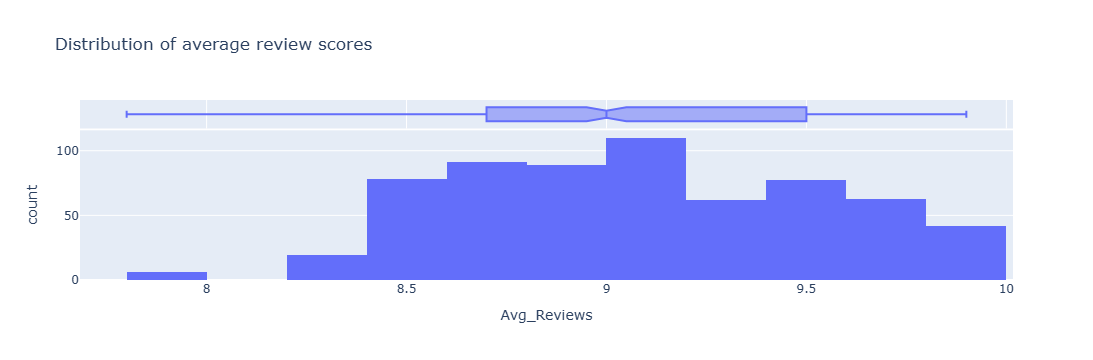

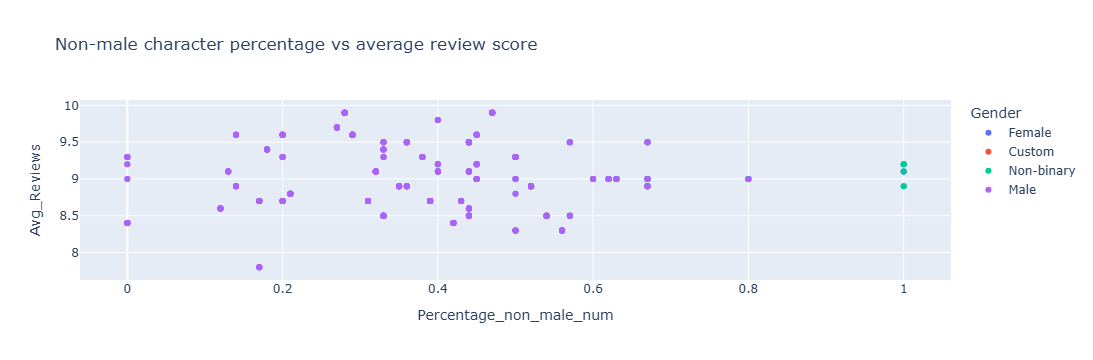

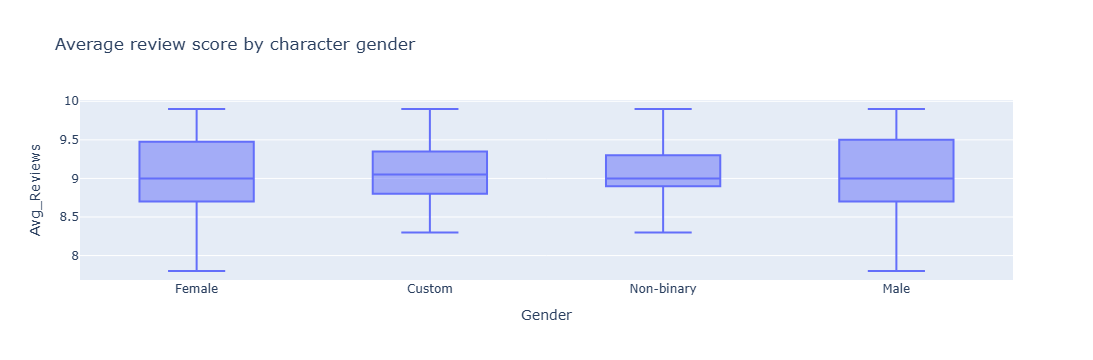

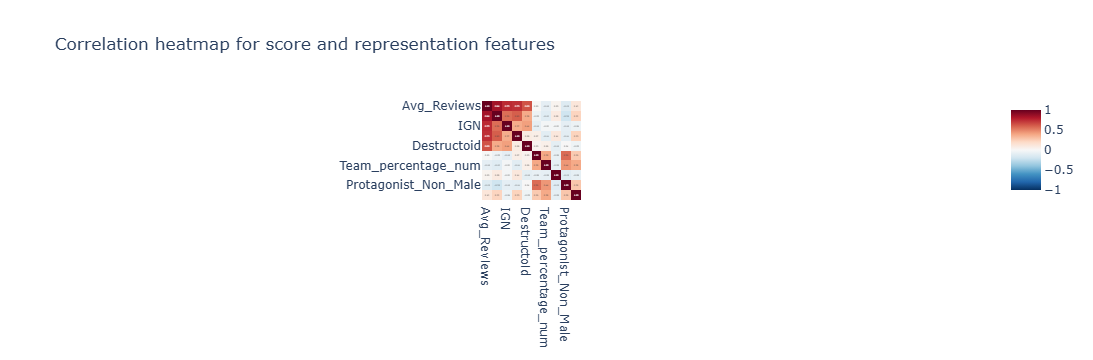

,count,mean,std,min,25%,50%,75%,max
Avg_Reviews,637.000,9.051,0.451,7.800,8.700,9.000,9.500,9.900
Metacritic,637.000,8.917,0.474,7.900,8.700,8.900,9.300,9.700
IGN,605.000,9.297,0.544,8.000,9.000,9.300,9.800,10.000
GameSpot,608.000,8.855,0.782,7.000,8.500,9.000,9.000,10.000
Destructoid,573.000,9.125,0.687,7.000,8.600,9.000,9.500,10.000
Percentage_non_male_num,637.000,0.383,0.175,0.000,0.280,0.390,0.470,1.000
Team_percentage_num,637.000,0.109,0.178,0.000,0.000,0.000,0.170,0.670
Sexualization,637.000,0.086,0.389,0.000,0.000,0.000,0.000,3.000
Protagonist_Non_Male,637.000,0.501,0.554,0.000,0.000,0.000,1.000,2.000
Release_Year,637.000,2016.911,3.081,2012.000,2014.000,2017.000,2019.000,2022.000


In [4]:
eda_features = [
    "Avg_Reviews",
    "Metacritic",
    "IGN",
    "GameSpot",
    "Destructoid",
    "Percentage_non_male_num",
    "Team_percentage_num",
    "Sexualization",
    "Protagonist_Non_Male",
    "Release_Year",
]
eda_features = [column for column in eda_features if column in df.columns]

fig_reviews = px.histogram(
    df,
    x="Avg_Reviews",
    nbins=20,
    marginal="box",
    title="Distribution of average review scores",
)
fig_reviews.show()

if {"Percentage_non_male_num", "Avg_Reviews"}.issubset(df.columns):
    fig_representation = px.scatter(
        df,
        x="Percentage_non_male_num",
        y="Avg_Reviews",
        color="Gender" if "Gender" in df.columns else None,
        hover_name="Title" if "Title" in df.columns else None,
        title="Non-male character percentage vs average review score",
    )
    fig_representation.show()

if {"Gender", "Avg_Reviews"}.issubset(df.columns):
    fig_gender_box = px.box(
        df,
        x="Gender",
        y="Avg_Reviews",
        points="outliers",
        title="Average review score by character gender",
    )
    fig_gender_box.show()

correlation_df = df[eda_features].corr(numeric_only=True)
fig_heatmap = px.imshow(
    correlation_df,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation heatmap for score and representation features",
)
fig_heatmap.show()

display(df[eda_features].describe().T)

## Metrics Guide

For the regression models:

- **MSE**: averages squared errors and keeps the penalty on larger misses explicit.
- **RMSE**: takes the square root of MSE so the error returns to the original score scale.
- **MAE**: measures the average absolute miss and is easier to interpret in score units.
- **R2**: estimates how much of the variation in review scores is explained by the model.

For the Naive Bayes classifier:

- **Accuracy**: overall share of correct predictions.
- **Precision**: among games predicted as high-scoring, how many truly are high-scoring.
- **Recall**: among truly high-scoring games, how many the classifier catches.
- **F1**: a balance between precision and recall.

Naive Bayes is a classifier rather than a regressor, so we turn `Avg_Reviews` into a binary label: high score (`>= 9.0`) vs lower score (`< 9.0`). The `9.0` threshold is used here because a lower cutoff such as `7.5` would collapse this dataset into almost a single class.

In [5]:
target = "Avg_Reviews"
regression_features = [
    "Metacritic",
    "IGN",
    "GameSpot",
    "Destructoid",
    "Percentage_non_male_num",
    "Sexualization",
    "Protagonist_Non_Male",
    "Team_percentage_num",
    "Release_Year",
    "PEGI",
]
feature_columns = regression_features
target_column = target

train_state = restore_data(
    df,
    regression_features,
    target,
    split_pct=int(TEST_SIZE * 100),
)

X_train = train_state["X_train"]
X_test = train_state["X_val"]
y_train = train_state["y_train"]
y_test = train_state["y_val"]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print(f"Target: {target}")
print(f"Features: {', '.join(regression_features)}")

Training rows: 399
Testing rows: 172
Target: Avg_Reviews
Features: Metacritic, IGN, GameSpot, Destructoid, Percentage_non_male_num, Sexualization, Protagonist_Non_Male, Team_percentage_num, Release_Year, PEGI


In [6]:
regression_models = {
    "Multiple Linear Regression": LinearRegression(),
    "Ridge Regression": RidgeCV(alphas=np.logspace(-3, 2, 60)),
    "Lasso Regression": LassoCV(
        alphas=np.logspace(-3, 1, 60),
        cv=5,
        max_iter=20000,
        random_state=RANDOM_STATE,
    ),
}

fitted_regression_models = {}
regression_rows = []

for model_name, estimator in regression_models.items():
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    metric_values = compute_eval_metrics(
        X_test,
        y_test,
        pipeline,
        [
            "mean_squared_error",
            "mean_absolute_error",
            "root_mean_squared_error",
            "r2_score",
        ],
    )

    row = {
        "Model": model_name,
        "MSE": metric_values["mean_squared_error"],
        "RMSE": metric_values["root_mean_squared_error"],
        "MAE": metric_values["mean_absolute_error"],
        "R2": metric_values["r2_score"],
    }
    if hasattr(pipeline.named_steps["model"], "alpha_"):
        row["Selected alpha"] = pipeline.named_steps["model"].alpha_

    regression_rows.append(row)
    fitted_regression_models[model_name] = pipeline

regression_results = pd.DataFrame(regression_rows).sort_values("RMSE").reset_index(drop=True)
display(regression_results)

C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



,Model,MSE,RMSE,MAE,R2,Selected alpha
0,Ridge Regression,0.001,0.029,0.025,0.996,0.001
1,Multiple Linear Regression,0.001,0.029,0.025,0.996,NaN
2,Lasso Regression,0.001,0.029,0.025,0.996,0.001


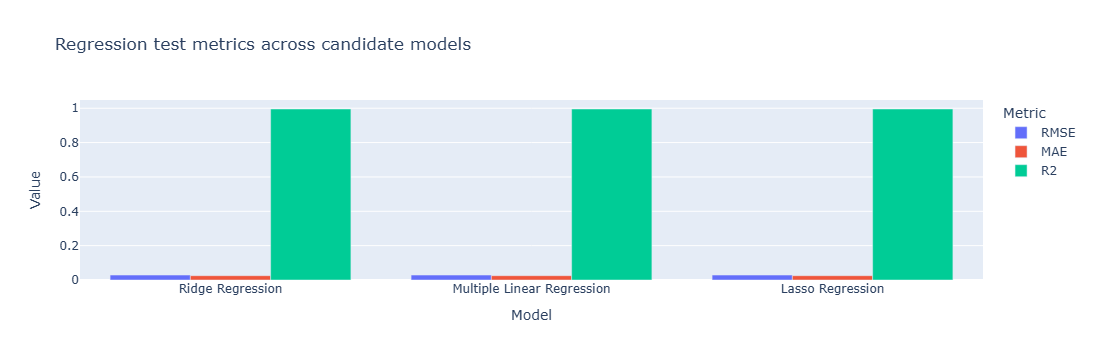

In [7]:
metric_long_df = regression_results.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE", "R2"],
    var_name="Metric",
    value_name="Value",
)

fig_metric_bars = px.bar(
    metric_long_df,
    x="Model",
    y="Value",
    color="Metric",
    barmode="group",
    title="Regression test metrics across candidate models",
)
fig_metric_bars.show()

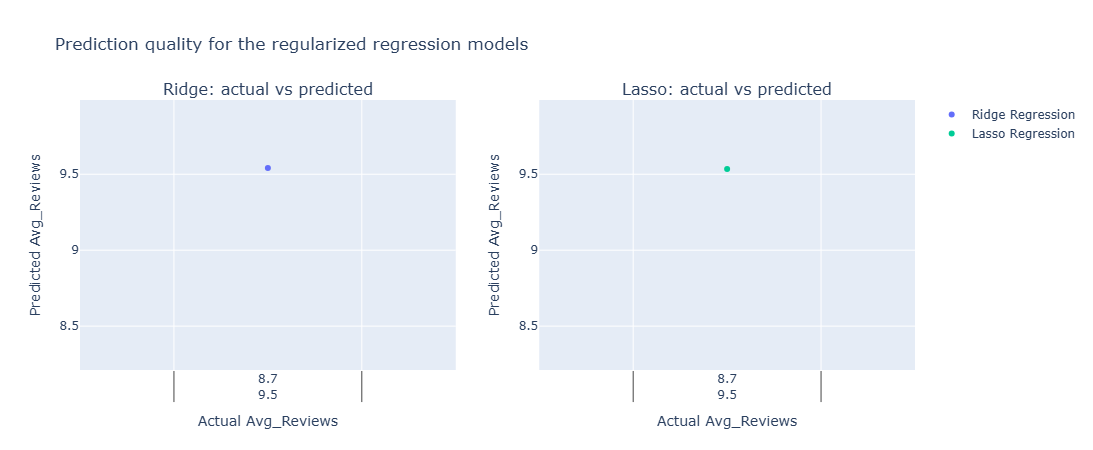

In [8]:
fig_predictions = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Ridge: actual vs predicted", "Lasso: actual vs predicted"),
)

for index, model_name in enumerate(["Ridge Regression", "Lasso Regression"], start=1):
    predictions = fitted_regression_models[model_name].predict(X_test)
    fig_predictions.add_trace(
        go.Scatter(
            x=y_test,
            y=predictions,
            mode="markers",
            name=model_name,
        ),
        row=1,
        col=index,
    )
    fig_predictions.add_trace(
        go.Scatter(
            x=[y_test.min(), y_test.max()],
            y=[y_test.min(), y_test.max()],
            mode="lines",
            line=dict(color="black", dash="dash"),
            showlegend=False,
        ),
        row=1,
        col=index,
    )

fig_predictions.update_xaxes(title_text="Actual Avg_Reviews")
fig_predictions.update_yaxes(title_text="Predicted Avg_Reviews")
fig_predictions.update_layout(height=450, title="Prediction quality for the regularized regression models")
fig_predictions.show()

,Feature,Coefficient,Model
12,GameSpot,0.195,Lasso Regression
13,Destructoid,0.175,Lasso Regression
11,IGN,0.135,Lasso Regression
10,Metacritic,0.128,Lasso Regression
19,PEGI,0.006,Lasso Regression
17,Team_percentage_num,0.002,Lasso Regression
18,Release_Year,0.001,Lasso Regression
15,Sexualization,0.000,Lasso Regression
14,Percentage_non_male_num,-0.000,Lasso Regression
16,Protagonist_Non_Male,-0.000,Lasso Regression


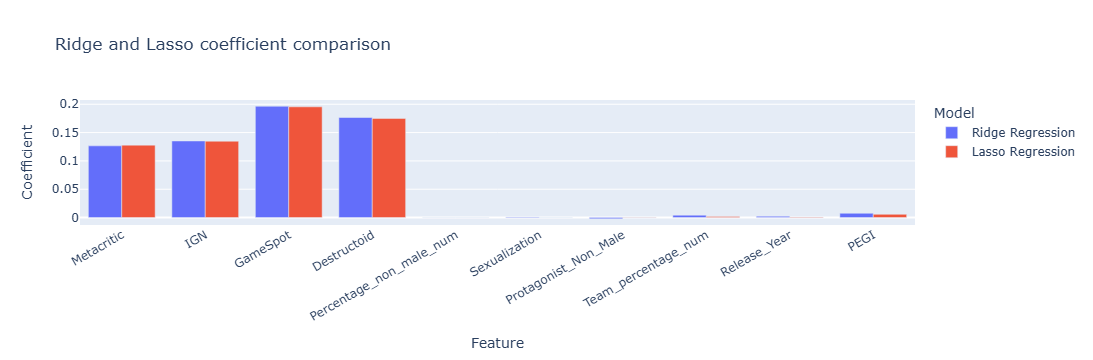

In [9]:
coefficient_rows = []
for model_name in ["Ridge Regression", "Lasso Regression"]:
    coefficients = fitted_regression_models[model_name].named_steps["model"].coef_
    coefficient_rows.extend(
        {
            "Feature": feature,
            "Coefficient": coefficient,
            "Model": model_name,
        }
        for feature, coefficient in zip(regression_features, coefficients)
    )

coefficient_df = pd.DataFrame(coefficient_rows)
display(coefficient_df.sort_values(["Model", "Coefficient"], ascending=[True, False]))

fig_coefficients = px.bar(
    coefficient_df,
    x="Feature",
    y="Coefficient",
    color="Model",
    barmode="group",
    title="Ridge and Lasso coefficient comparison",
)
fig_coefficients.update_layout(xaxis_tickangle=-30)
fig_coefficients.show()

In [10]:
# Features
X = df[feature_columns]

# Target column name
target = "Avg_Reviews"

nb_target = (df[target] >= NB_HIGH_SCORE_THRESHOLD).astype(int)

## Requested Naive Bayes Analysis Using IGN Thresholds

This section follows the requested rule exactly:

- `high` if normalized `IGN > 0.95`
- `low` if normalized `IGN < 0.9`

To make the thresholds match the `0.0` to `1.0` scale, the notebook divides `IGN` by `10`. Games in the middle band (`0.7` to `0.9`) are excluded from this specific experiment.

,Class,Count
0,high,179
1,low,123


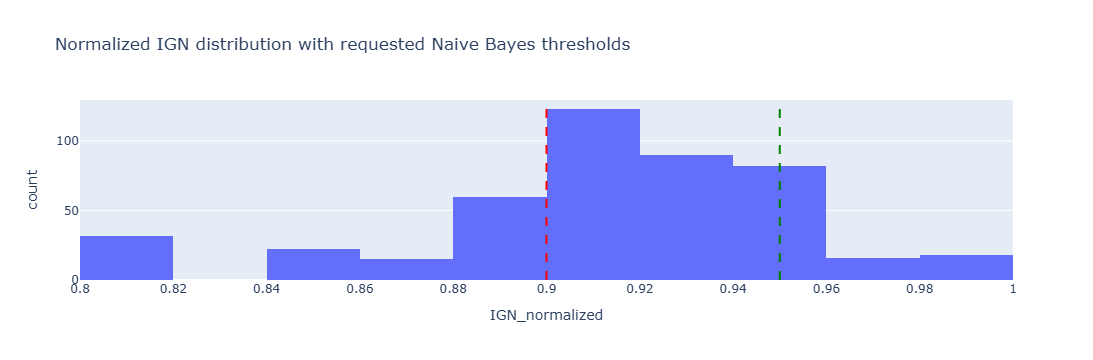

,Metric,Value
0,Accuracy,1.000
1,Precision,1.000
2,Recall,1.000
3,F1,1.000


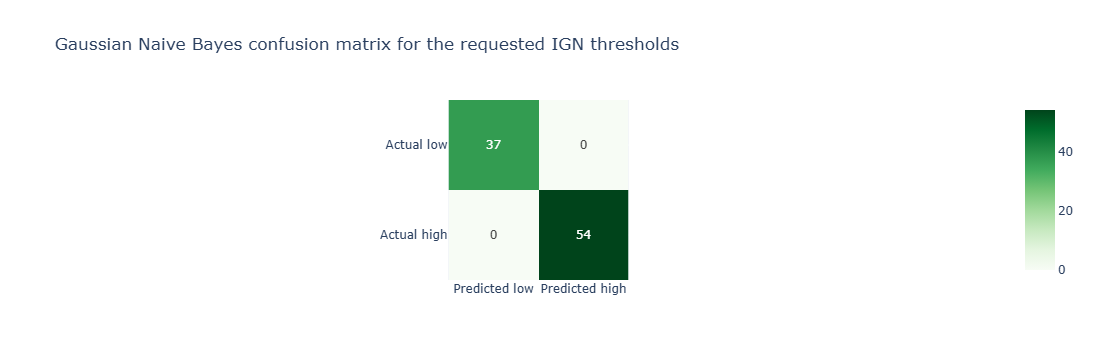

In [11]:
ign_nb_columns = list(dict.fromkeys(regression_features + ["IGN"]))
ign_nb_df = df[ign_nb_columns].dropna().copy()
ign_nb_df["IGN_normalized"] = ign_nb_df["IGN"] / 10

ign_nb_df = ign_nb_df.loc[
    (ign_nb_df["IGN_normalized"] > IGN_HIGH_THRESHOLD)
    | (ign_nb_df["IGN_normalized"] < IGN_LOW_THRESHOLD)
].copy()

ign_nb_df["IGN_label"] = np.where(
    ign_nb_df["IGN_normalized"] > IGN_HIGH_THRESHOLD,
    "high",
    "low",
)

class_counts = ign_nb_df["IGN_label"].value_counts().rename_axis("Class").reset_index(name="Count")
display(class_counts)

fig_ign_thresholds = px.histogram(
    df.assign(IGN_normalized=df["IGN"] / 10),
    x="IGN_normalized",
    nbins=20,
    title="Normalized IGN distribution with requested Naive Bayes thresholds",
)
fig_ign_thresholds.add_vline(x=IGN_LOW_THRESHOLD, line_dash="dash", line_color="red")
fig_ign_thresholds.add_vline(x=IGN_HIGH_THRESHOLD, line_dash="dash", line_color="green")
fig_ign_thresholds.show()

if ign_nb_df["IGN_label"].nunique() < 2:
    print(
        "The requested IGN-threshold split cannot train Gaussian Naive Bayes on the current dataset, "
        "because only one class is present after filtering."
    )
else:
    X_ign_nb = ign_nb_df[regression_features]
    y_ign_nb = (ign_nb_df["IGN_label"] == "high").astype(int)

    X_train_ign_nb, X_test_ign_nb, y_train_ign_nb, y_test_ign_nb = train_test_split(
        X_ign_nb,
        y_ign_nb,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_ign_nb,
    )

    ign_nb_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", GaussianNB()),
    ])
    ign_nb_pipeline.fit(X_train_ign_nb, y_train_ign_nb)
    ign_nb_predictions = ign_nb_pipeline.predict(X_test_ign_nb)

    ign_nb_results = pd.DataFrame([
        {"Metric": "Accuracy", "Value": accuracy(y_test_ign_nb, ign_nb_predictions)},
        {"Metric": "Precision", "Value": precision(y_test_ign_nb, ign_nb_predictions)},
        {"Metric": "Recall", "Value": recall(y_test_ign_nb, ign_nb_predictions)},
        {"Metric": "F1", "Value": f1_score(y_test_ign_nb, ign_nb_predictions)},
    ])
    display(ign_nb_results)

    ign_nb_confusion = confusion_matrix(y_test_ign_nb, ign_nb_predictions)
    fig_ign_nb_confusion = px.imshow(
        ign_nb_confusion,
        text_auto=True,
        color_continuous_scale="Greens",
        x=["Predicted low", "Predicted high"],
        y=["Actual low", "Actual high"],
        title="Gaussian Naive Bayes confusion matrix for the requested IGN thresholds",
    )
    fig_ign_nb_confusion.show()

## Key Takeaways

- Multiple Linear, Ridge, and Lasso provide the main regression comparison, with the held-out split summarized by MSE, RMSE, MAE, and R2.
- The coefficient plot helps explain which features contribute most strongly after scaling and regularization.
- Naive Bayes is included as a separate classification view of the problem: it predicts whether a game falls into the high-score group rather than estimating the exact review score.
- The additional IGN-threshold Naive Bayes analysis now checks the requested rule of `IGN > 0.95` for high and `IGN < 0.9` for low after normalizing IGN to a `0` to `1` scale, while excluding the middle band.
- Because `Avg_Reviews` is closely tied to the critic-site scores (`Metacritic`, `IGN`, `GameSpot`, `Destructoid`), those features will typically dominate predictive performance. Representation-related variables still appear in the workflow, but they should be interpreted as supporting signals rather than the sole driver of the score.